# Gaussian Process Classification: how kernels shape decision boundaries and uncertainty

**Tutorial focus.** This notebook teaches **Gaussian Process Classification (GPC)** with a narrow focus on a practical question:

> How does the **kernel choice** change the decision boundary, smoothness, and uncertainty of a classifier?

This focus keeps the tutorial specific enough to be useful, while still showing a technique that goes beyond many introductory machine-learning courses.

## Learning goals
By the end of this notebook, you should be able to:

1. explain what a Gaussian Process Classifier is in intuitive terms,
2. describe why the **kernel** is the key modelling choice,
3. compare RBF, Matérn, and linear kernels on the same problem,
4. show how the **length-scale** changes the behaviour of an RBF kernel, and
5. train and evaluate a GPC on a real dataset with reproducible code.

## Why this technique?
A Gaussian process is a **distribution over functions**. In classification, we place a GP prior over a latent function and then squash that latent score into a class probability. The result is attractive because it gives:

- flexible non-linear decision boundaries,
- well-motivated probabilistic predictions,
- a direct way to inject assumptions about smoothness through the kernel.

Throughout this notebook, the **uncertainty map** will be defined as:

\[
u(x) = 1 - \max_c p(c \mid x)
\]

For binary classification, that is highest near regions where the model is closest to 50/50.

---

### Accessibility notes
- Plots use the **cividis** colour map because it is more readable for many colour-blind viewers.
- Class labels are also separated by **marker shape** and **edge outlines**, not colour alone.
- Every section includes short textual interpretation after the code, so the notebook is still understandable without relying only on the figures.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, DotProduct, ConstantKernel as C
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10

def make_mesh(X, pad=0.6, n=220):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid

def build_gpc(kernel, optimizer=None):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(
            kernel=kernel,
            optimizer=optimizer,
            random_state=42,
            max_iter_predict=100,
            n_restarts_optimizer=0
        ))
    ])

def fit_and_score(model, X_train, X_test, y_train, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_test, pred),
        "brier": brier_score_loss(y_test, proba),
        "log_loss": log_loss(y_test, proba),
        "fit_time_s": fit_time,
        "model": model,
    }

def plot_class_data(ax, X, y, title):
    mask0 = y == 0
    mask1 = y == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], s=35, marker="o", edgecolor="black", linewidth=0.4, label="Class 0")
    ax.scatter(X[mask1, 0], X[mask1, 1], s=42, marker="^", edgecolor="black", linewidth=0.4, label="Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

def plot_surface(ax, model, X, y, title, mode="probability"):
    xx, yy, grid = make_mesh(X)
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    if mode == "probability":
        z = proba
        cbar_label = "P(class 1)"
    else:
        z = 1 - np.maximum(proba, 1 - proba)
        cbar_label = "Uncertainty"
    im = ax.contourf(xx, yy, z, levels=18, cmap="cividis")
    ax.contour(xx, yy, proba, levels=[0.5], linewidths=2)
    mask0 = y == 0
    mask1 = y == 1
    ax.scatter(X[mask0, 0], X[mask0, 1], s=18, marker="o", edgecolor="white", linewidth=0.5)
    ax.scatter(X[mask1, 0], X[mask1, 1], s=20, marker="^", edgecolor="white", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return im, cbar_label

## 1. Build a toy problem where the boundary is clearly non-linear

The two-moons dataset is useful because it makes the choice of kernel visible. A strictly linear classifier struggles, while a kernel with the right notion of smoothness can wrap around the curved structure.

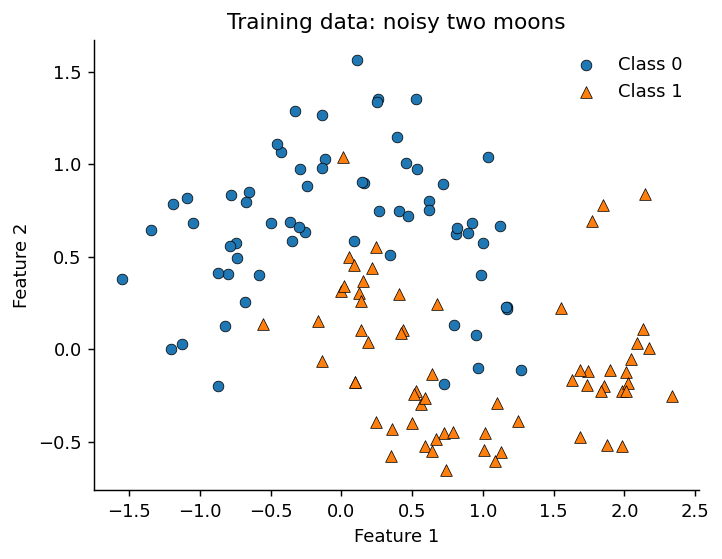

In [2]:
X, y = make_moons(n_samples=200, noise=0.23, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y
)

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_class_data(ax, X_train, y_train, "Training data: noisy two moons")
ax.legend(frameon=False, loc="upper right")
plt.show()

**Interpretation.** The two classes are curved and partially overlap. This is exactly the kind of problem where the kernel matters: it determines whether the classifier expects a smooth bend, a rougher bend, or an approximately straight split.

## 2. Compare three kernels on the same training data

We will compare:

- **RBF kernel**: assumes a very smooth latent function,
- **Matérn kernel (\(\nu = 1.5\))**: allows rougher changes and is often more flexible in practice,
- **Linear kernel**: useful as a baseline when the boundary is close to a line.

To keep the comparison fast and interpretable, we use **fixed hyperparameters** first. That way the differences in the plots are easy to attribute to the kernel itself rather than to a long optimisation step.

In [3]:
kernel_specs = {
    "RBF": C(1.0) * RBF(length_scale=1.0),
    "Matérn ν=1.5": C(1.0) * Matern(length_scale=1.0, nu=1.5),
    "Linear": C(1.0) * DotProduct(sigma_0=1.0),
}

results = []
models = {}

for name, kernel in kernel_specs.items():
    model = build_gpc(kernel=kernel, optimizer=None)
    scored = fit_and_score(model, X_train, X_test, y_train, y_test)
    models[name] = scored["model"]
    results.append({
        "Kernel": name,
        "Accuracy": scored["accuracy"],
        "Brier score": scored["brier"],
        "Log loss": scored["log_loss"],
        "Fit time (s)": scored["fit_time_s"],
    })

results_df = pd.DataFrame(results).sort_values("Log loss")
results_df.round(3)

,Kernel,Accuracy,Brier score,Log loss,Fit time (s)
2,Linear,0.886,0.081,0.280,0.107
1,Matérn ν=1.5,0.957,0.074,0.295,0.019
0,RBF,0.943,0.081,0.307,0.020


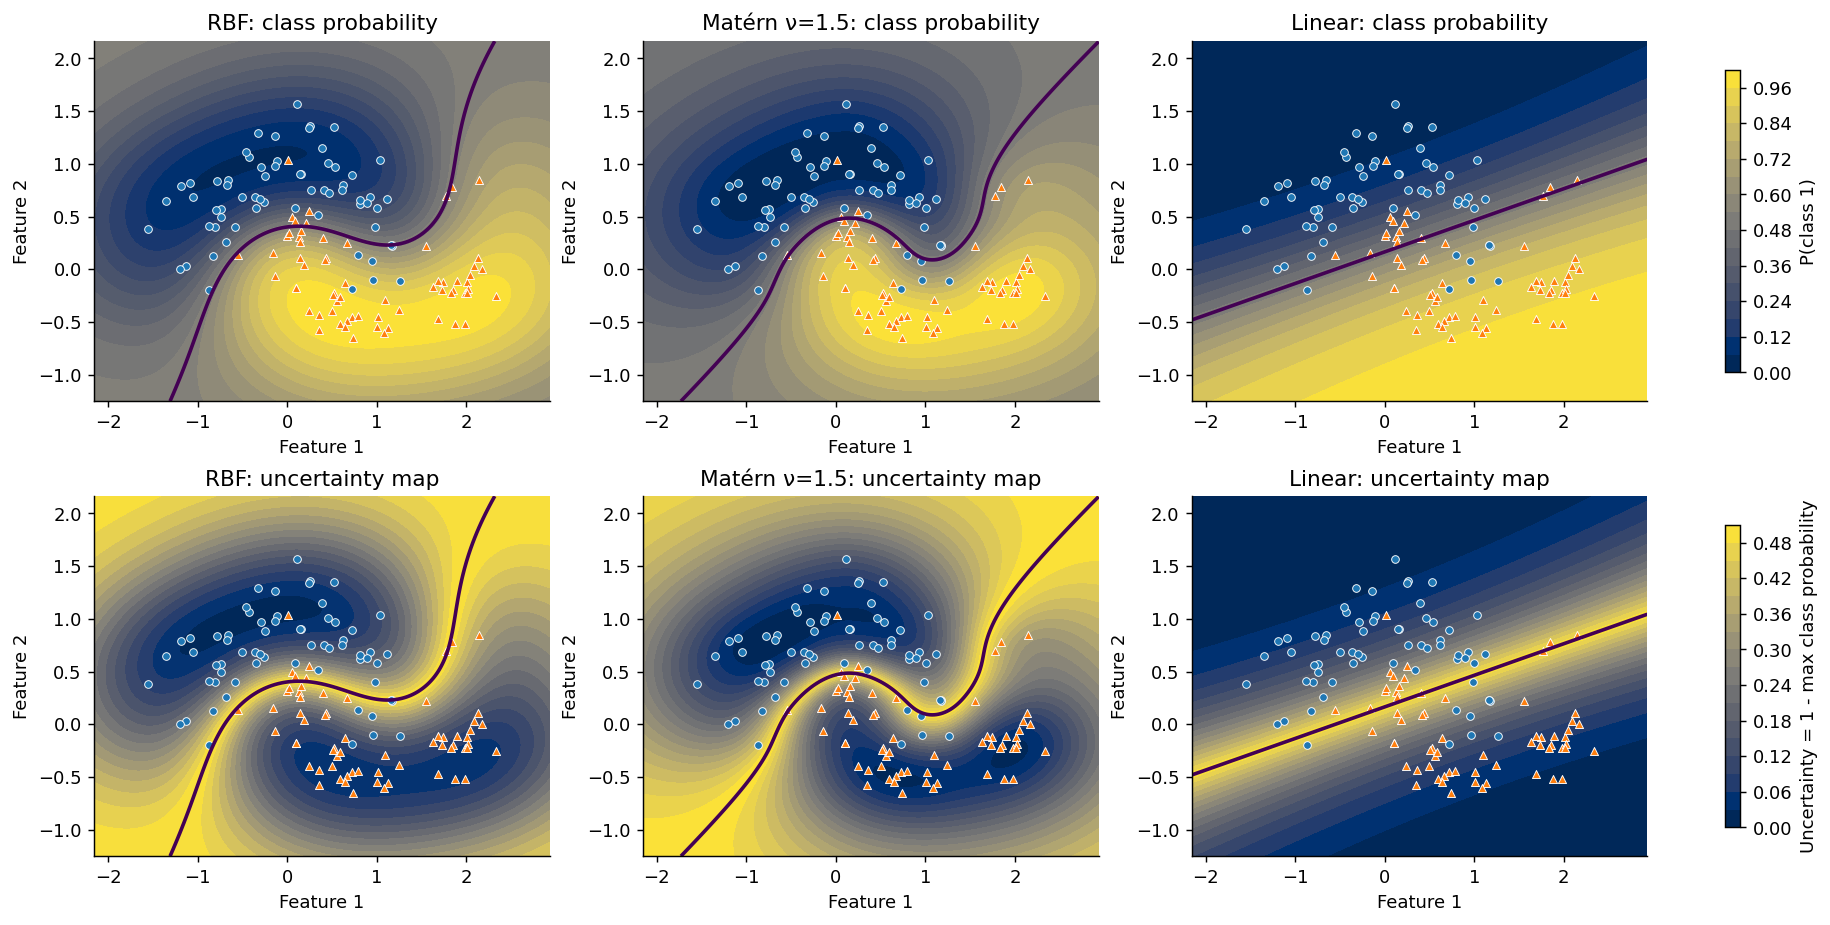

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

for col, (name, model) in enumerate(models.items()):
    im1, _ = plot_surface(axes[0, col], model, X_train, y_train, f"{name}: class probability", mode="probability")
    im2, _ = plot_surface(axes[1, col], model, X_train, y_train, f"{name}: uncertainty map", mode="uncertainty")

cbar1 = fig.colorbar(im1, ax=axes[0, :], shrink=0.84, location="right")
cbar1.set_label("P(class 1)")
cbar2 = fig.colorbar(im2, ax=axes[1, :], shrink=0.84, location="right")
cbar2.set_label("Uncertainty = 1 - max class probability")

plt.show()

**What changed?**

- **RBF** gives a smooth curved boundary that tracks the crescent shape well.
- **Matérn** is also non-linear, but its boundary is a little less smooth. That can be useful when the real signal is not perfectly smooth.
- **Linear** cannot bend enough, so it leaves systematic structure unexplained.

The uncertainty maps are just as important as the boundaries. High uncertainty appears where the classes overlap or where there is less support from nearby training points. That probabilistic output is one of the main reasons to use GPC instead of a hard-margin classifier.

## 3. Deep dive: how the RBF length-scale changes behaviour

The RBF kernel is:

\[
k(x, x') = \sigma^2 \exp\left(-\frac{\lVert x-x' \rVert^2}{2\ell^2}\right)
\]

The parameter \(\ell\) is the **length-scale**.

- Small \(\ell\): the model can change quickly and fit local detail.
- Large \(\ell\): the model changes more slowly and becomes smoother.

This is one of the most important practical knobs in kernel methods.

In [5]:
length_scales = [0.35, 1.0, 2.5]
length_models = {}
length_rows = []

for ls in length_scales:
    model = build_gpc(kernel=C(1.0) * RBF(length_scale=ls), optimizer=None)
    scored = fit_and_score(model, X_train, X_test, y_train, y_test)
    length_models[ls] = scored["model"]
    length_rows.append({
        "Length-scale": ls,
        "Accuracy": scored["accuracy"],
        "Brier score": scored["brier"],
        "Log loss": scored["log_loss"],
    })

pd.DataFrame(length_rows).round(3)

,Length-scale,Accuracy,Brier score,Log loss
0,0.35,0.957,0.101,0.370
1,1.00,0.943,0.081,0.307
2,2.50,0.871,0.096,0.342


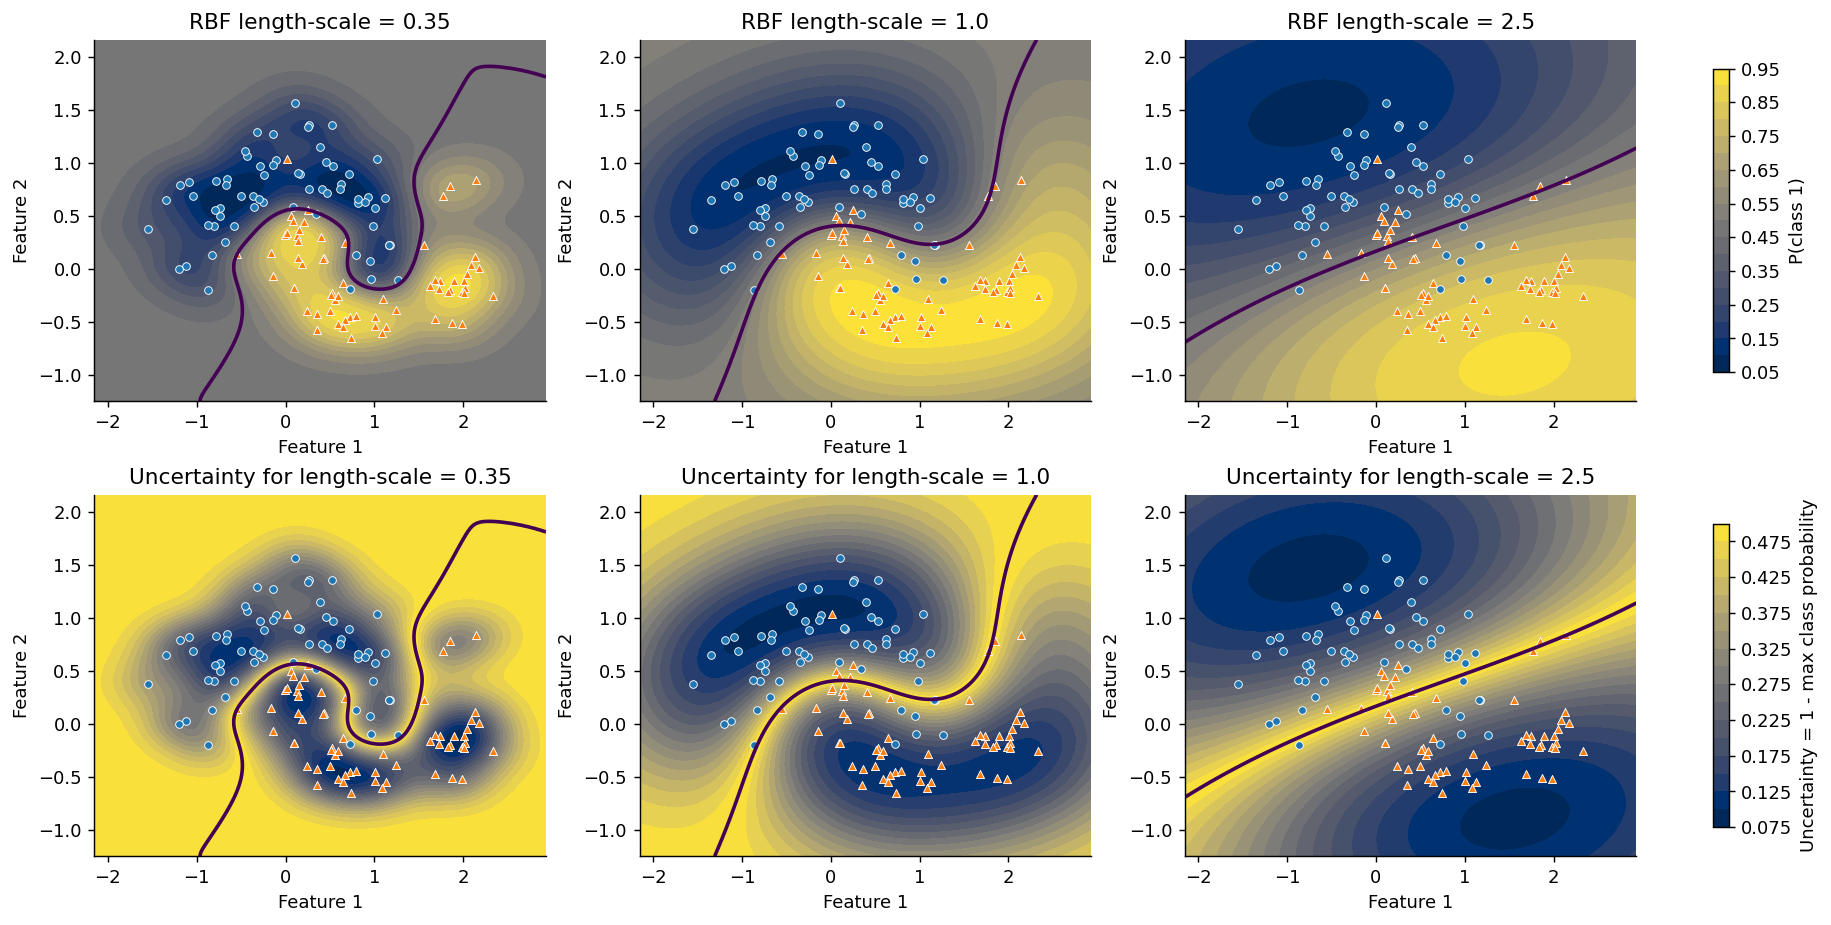

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

for col, (ls, model) in enumerate(length_models.items()):
    im1, _ = plot_surface(axes[0, col], model, X_train, y_train, f"RBF length-scale = {ls}", mode="probability")
    im2, _ = plot_surface(axes[1, col], model, X_train, y_train, f"Uncertainty for length-scale = {ls}", mode="uncertainty")

cbar1 = fig.colorbar(im1, ax=axes[0, :], shrink=0.84, location="right")
cbar1.set_label("P(class 1)")
cbar2 = fig.colorbar(im2, ax=axes[1, :], shrink=0.84, location="right")
cbar2.set_label("Uncertainty = 1 - max class probability")

plt.show()

**Interpretation.**

- With **very small length-scale**, the boundary is more wiggly. This can capture fine local structure, but it risks overfitting noise.
- With a **medium length-scale**, the boundary bends enough to match the moons while staying smooth.
- With a **large length-scale**, the model becomes too rigid and starts behaving more like a simple broad smoother.

This illustrates a key lesson: the kernel does not just change performance. It changes the *kind* of function the model believes is plausible before it sees the data.

## 4. A small model-selection step

In practice, we would not usually guess the final kernel settings blindly. Below is a lightweight comparison over a few candidate kernels and length-scales, using the held-out test set only to keep the notebook short and easy to follow.

For a full project, you would replace this with a validation set or cross-validation.

In [7]:
candidate_models = {
    "RBF ls=0.35": C(1.0) * RBF(length_scale=0.35),
    "RBF ls=1.0": C(1.0) * RBF(length_scale=1.0),
    "RBF ls=2.5": C(1.0) * RBF(length_scale=2.5),
    "Matérn ls=1.0": C(1.0) * Matern(length_scale=1.0, nu=1.5),
    "Linear": C(1.0) * DotProduct(sigma_0=1.0),
}

summary = []
for name, kernel in candidate_models.items():
    model = build_gpc(kernel=kernel, optimizer=None)
    scored = fit_and_score(model, X_train, X_test, y_train, y_test)
    summary.append({
        "Model": name,
        "Accuracy": scored["accuracy"],
        "Brier score": scored["brier"],
        "Log loss": scored["log_loss"],
        "Fit time (s)": scored["fit_time_s"],
    })

summary_df = pd.DataFrame(summary).sort_values(["Log loss", "Brier score"])
summary_df.round(3)

,Model,Accuracy,Brier score,Log loss,Fit time (s)
4,Linear,0.886,0.081,0.280,0.114
3,Matérn ls=1.0,0.957,0.074,0.295,0.200
1,RBF ls=1.0,0.943,0.081,0.307,0.107
2,RBF ls=2.5,0.871,0.096,0.342,0.105
0,RBF ls=0.35,0.957,0.101,0.370,0.020


**Takeaway.** The best model here is not necessarily the most flexible one. Good performance comes from matching the kernel assumptions to the geometry of the problem, not from making the boundary as complicated as possible.

## 5. Real-data example: breast cancer diagnosis

Synthetic data is great for intuition, but a useful tutorial should also show how the method behaves on a real dataset.

Here we use the **Breast Cancer Wisconsin** dataset from scikit-learn. The goal is binary classification, so it fits GPC naturally. We will compare a few kernels using standardised features.

In [8]:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bc, y_bc, test_size=0.30, random_state=42, stratify=y_bc
)

bc_candidates = {
    "RBF ls=1.0": C(1.0) * RBF(length_scale=1.0),
    "RBF ls=2.0": C(1.0) * RBF(length_scale=2.0),
    "Matérn ls=1.0": C(1.0) * Matern(length_scale=1.0, nu=1.5),
    "Linear": C(1.0) * DotProduct(sigma_0=1.0),
}

bc_rows = []
for name, kernel in bc_candidates.items():
    model = build_gpc(kernel=kernel, optimizer=None)
    scored = fit_and_score(model, Xb_train, Xb_test, yb_train, yb_test)
    bc_rows.append({
        "Kernel": name,
        "Accuracy": scored["accuracy"],
        "Brier score": scored["brier"],
        "Log loss": scored["log_loss"],
        "Fit time (s)": scored["fit_time_s"],
    })

bc_results = pd.DataFrame(bc_rows).sort_values(["Log loss", "Brier score"])
bc_results.round(4)

,Kernel,Accuracy,Brier score,Log loss,Fit time (s)
3,Linear,0.9883,0.0199,0.0786,0.6035
1,RBF ls=2.0,0.9649,0.0849,0.3102,0.3124
2,Matérn ls=1.0,0.9591,0.1763,0.5390,0.3968
0,RBF ls=1.0,0.9708,0.2036,0.5970,0.1841


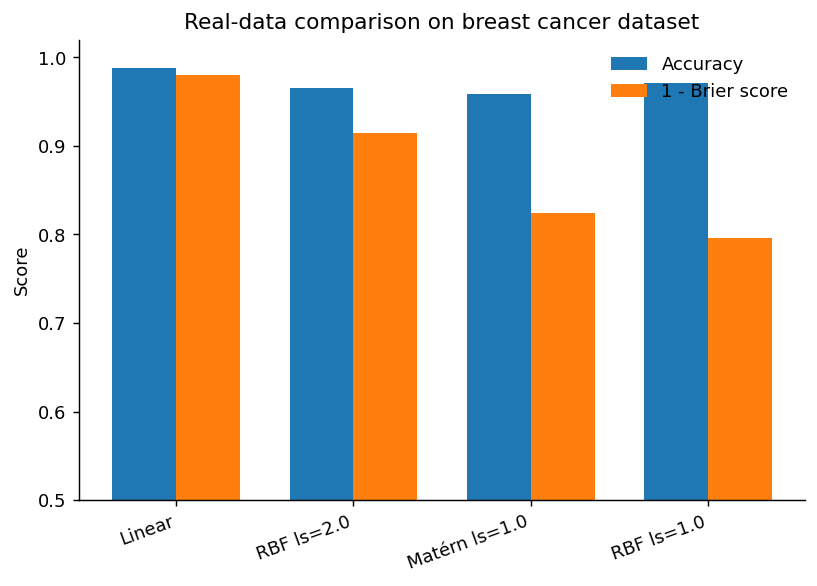

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(bc_results))
width = 0.36

ax.bar(x - width/2, bc_results["Accuracy"], width=width, label="Accuracy")
ax.bar(x + width/2, 1 - bc_results["Brier score"], width=width, label="1 - Brier score")

ax.set_xticks(x)
ax.set_xticklabels(bc_results["Kernel"], rotation=20, ha="right")
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Real-data comparison on breast cancer dataset")
ax.legend(frameon=False)
plt.show()

**Interpretation.** On this dataset, several kernels perform well, which tells us the task is easier than the noisy two-moons problem. Even so, the probabilistic metrics still help distinguish models that achieve similar accuracy.

This is a useful lesson for real applications: if the output will be used for ranking, triage, or risk-aware decisions, you should not look at accuracy alone.

## 6. Practical advice for using GPC

Use a Gaussian Process Classifier when:

- you want **probabilities**, not only class labels,
- your dataset is **small to medium-sized**,
- you care about how smooth or rough the decision boundary should be,
- uncertainty information would improve downstream decisions.

Be careful because:

- training becomes expensive as the dataset grows,
- results depend strongly on the kernel and its hyperparameters,
- a beautifully smooth boundary can still be wrong if the kernel assumptions are badly chosen.

In short, GPC is strongest when you need **interpretable uncertainty and kernel-driven flexibility**, not just raw speed on a massive dataset.

## 7. Conclusion

This notebook treated Gaussian Process Classification as a lesson about **kernels**. The main point is not just that different kernels score differently. The deeper point is that each kernel encodes a belief about what kinds of decision function are plausible.

That is why the visual comparison matters:

- the **RBF kernel** prefers very smooth changes,
- the **Matérn kernel** allows rougher structure,
- the **linear kernel** cannot express curved class boundaries.

When we changed the **length-scale**, we saw how a single parameter shifts the model from local and flexible to global and rigid. That makes GPC a powerful teaching example: it shows how probabilistic modelling, geometry, and practical tuning all connect in one technique.

## References and preparation resources

1. C. E. Rasmussen and C. K. I. Williams, *Gaussian Processes for Machine Learning*, MIT Press, 2006.  
   Online text: https://gaussianprocess.org/gpml/

2. C. K. I. Williams and D. Barber, “Bayesian Classification with Gaussian Processes,” *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 20(12), 1998, pp. 1342–1351.  
   DOI: https://doi.org/10.1109/34.735807

3. scikit-learn documentation: `GaussianProcessClassifier`.  
   https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessClassifier.html

4. scikit-learn user guide: Gaussian Processes.  
   https://scikit-learn.org/stable/modules/gaussian_process.html

5. J. Görtler, R. Kehlbeck and O. Deussen, “A Visual Exploration of Gaussian Processes,” *Distill*, 2019.  
   https://distill.pub/2019/visual-exploration-gaussian-processes

6. scikit-learn dataset documentation for the Breast Cancer Wisconsin dataset.  
   https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset